# 🧬 RNN / LSTM — DNA Promoter Sequence Classification (PyTorch)
Public database: **UCI Molecular Biology (Promoter Gene Sequences)** — 106 E. coli promoter regions (57 bp). An LSTM reads the DNA sequence base-by-base and predicts whether it is a promoter (+).


In [1]:
# ============================================================
# Setup
# ============================================================
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# Dataset — UCI Molecular Biology (Promoter Gene Sequences)
# 106 E. coli DNA sequences (57 bp); classify promoter (+) vs non-promoter (-)
# ============================================================
URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "molecular-biology/promoter-gene-sequences/promoters.data")
req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})
text = urllib.request.urlopen(req, timeout=30).read().decode()

rows = []
for line in text.strip().splitlines():
    parts = line.split(",")
    rows.append((parts[0], parts[2].strip()))

df = pd.DataFrame(rows, columns=["label", "seq"])
df["y"] = (df["label"] == "+").astype(int)
print(f"Samples: {len(df)} | Sequence length: {len(df['seq'].iloc[0])} bp")
print(df["label"].value_counts())
display(df.head())


Device: cpu


Samples: 106 | Sequence length: 57 bp
label
+    53
-    53
Name: count, dtype: int64


,label,seq,y
0,+,tactagcaatacgcttgcgttcggtggttaagtatgtataatgcgc...,1
1,+,tgctatcctgacagttgtcacgctgattggtgtcgttacaatctaa...,1
2,+,gtactagagaactagtgcattagcttatttttttgttatcatgcta...,1
3,+,aattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaata...,1
4,+,tcgataattaactattgacgaaaagctgaaaaccactagaatgcgc...,1


In [2]:
# ============================================================
# One-hot encode DNA sequences -> (N, seq_len, 4)
# ============================================================
BASES = ["A", "C", "G", "T"]
base2idx = {b: i for i, b in enumerate(BASES)}


def one_hot_encode(seq, alphabet=BASES):
    mat = np.zeros((len(seq), len(alphabet)), dtype=np.float32)
    for i, ch in enumerate(seq.upper()):     # UCI sequences are lowercase
        if ch in base2idx:
            mat[i, base2idx[ch]] = 1.0
    return mat


X = np.stack([one_hot_encode(s) for s in df["seq"]])   # (106, 57, 4)
y = df["y"].to_numpy()
print("Feature tensor shape:", X.shape)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Train: {len(y_train)} | Test: {len(y_test)}")


Feature tensor shape: (106, 57, 4)
Train: 79 | Test: 27


In [3]:
# ============================================================
# Define bidirectional LSTM model
# ============================================================
class LSTMPromoter(nn.Module):
    """Reads the DNA sequence position-by-position with an LSTM,
    then classifies using the last hidden state."""
    def __init__(self, input_size=4, hidden_size=32, num_layers=1,
                 num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)          # out: (B, seq, 2*hidden)
        last = out[:, -1, :]           # last timestep
        return self.fc(last)


model = LSTMPromoter().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters()):,}")


# ---- tensors ----
Xt = torch.tensor(X_train).to(device)
yt = torch.tensor(y_train, dtype=torch.long).to(device)
Xe = torch.tensor(X_test).to(device)
ye = torch.tensor(y_test, dtype=torch.long).to(device)


LSTMPromoter(
  (lstm): LSTM(4, 32, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)
Trainable params: 9,858


In [4]:
# ============================================================
# Training loop
# ============================================================
EPOCHS = 200
model.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    out = model(Xt)
    loss = criterion(out, yt)
    loss.backward()
    optimizer.step()
    if epoch == 1 or epoch % 20 == 0:
        with torch.no_grad():
            tr_acc = (out.argmax(1) == yt).float().mean().item()
            te_acc = (model(Xe).argmax(1) == ye).float().mean().item()
        print(f"Epoch {epoch:3d} | loss {loss.item():.4f} | "
              f"train acc {tr_acc:.4f} | test acc {te_acc:.4f}")


Epoch   1 | loss 0.6939 | train acc 0.5063 | test acc 0.4815


Epoch  20 | loss 0.6894 | train acc 0.5696 | test acc 0.5556


Epoch  40 | loss 0.6811 | train acc 0.5949 | test acc 0.5556


Epoch  60 | loss 0.6124 | train acc 0.6203 | test acc 0.6667


Epoch  80 | loss 0.4340 | train acc 0.8354 | test acc 0.7037


...

Epoch 120 | loss 0.3213 | train acc 0.8861 | test acc 0.6296


Epoch 140 | loss 0.2690 | train acc 0.8861 | test acc 0.7037


Epoch 160 | loss 0.2818 | train acc 0.8861 | test acc 0.7407


Epoch 180 | loss 0.2282 | train acc 0.8987 | test acc 0.7407


Epoch 200 | loss 0.2007 | train acc 0.9241 | test acc 0.7778


Test accuracy: 0.7778
                  precision    recall  f1-score   support

non-promoter (-)     0.7857    0.7857    0.7857        14
    promoter (+)     0.7692    0.7692    0.7692        13

        accuracy                         0.7778        27
       macro avg     0.7775    0.7775    0.7775        27
    weighted avg     0.7778    0.7778    0.7778        27



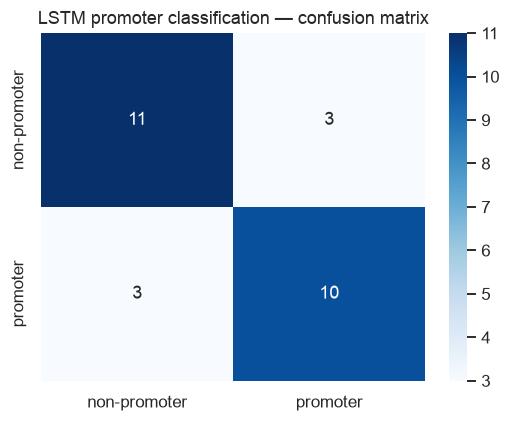

Example predictions (test set):
  [OK] true=promoter (+)     pred=promoter (+)     seq=tgaagtgcttagcttcaaggtcacggatacgaccgaagcgagcctcgtcctcaatgg
  [OK] true=promoter (+)     pred=promoter (+)     seq=ctatatgcgctcatacgatatgaacgttgagactgccgctgagttatcagctgtgaa
  [OK] true=non-promoter (-) pred=non-promoter (-) seq=gcggcagcacgtttccacgcggtgagagcctcaggattcatgtcgatgtcttccggt
  [OK] true=promoter (+)     pred=promoter (+)     seq=atccctaatgtctacttccggtcaatccatctacgttaaccgaggtggctatgtgta
  [OK] true=non-promoter (-) pred=non-promoter (-) seq=tggcgtctatcggtgaacctccggtatcaacgctggaaggtgacgctaacgcagatg
  [OK] true=non-promoter (-) pred=non-promoter (-) seq=tctcgtggatggacgttcaacattgaggaaggcataacgctactacctgatgtttac
  [OK] true=non-promoter (-) pred=non-promoter (-) seq=tattggcttgctcaagcatgaactcaaggctgatacggcgagacttgcgagccttgt
  [OK] true=promoter (+)     pred=promoter (+)     seq=tagagggtgtactccaagaagaggaagatgaggctagacgtctctgcatggagtatg


In [5]:
# ============================================================
# Evaluation
# ============================================================
with torch.no_grad():
    model.eval()
    y_pred = model(Xe).argmax(1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred,
                            target_names=["non-promoter (-)", "promoter (+)"],
                            digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["non-promoter", "promoter"],
            yticklabels=["non-promoter", "promoter"])
plt.title("LSTM promoter classification — confusion matrix")
plt.tight_layout(); plt.show()

# ---- example sequences + predictions ----
print("Example predictions (test set):")
for i in range(8):
    label = "promoter (+)" if y_pred[i] == 1 else "non-promoter (-)"
    true = "promoter (+)" if y_test[i] == 1 else "non-promoter (-)"
    mark = "OK" if y_pred[i] == y_test[i] else "MIS"
    print(f"  [{mark}] true={true:16s} pred={label:16s} "
          f"seq={df['seq'].iloc[len(y_train)+i]}")
